# Day 5 — Understanding Context Window in LLMs

One of the most important concepts in Large Language Models.

In [1]:
!pip install transformers matplotlib --quiet

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import matplotlib.pyplot as plt

MODEL_NAME = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

c:\Users\Nemochan\Desktop\ai-engineering-journey\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6108.07it/s]


## What is Context Window?

In [3]:
print("Context Window = Maximum number of tokens a model can 'remember' at once.")
print("GPT-2 Context Window = 1024 tokens")
print("If input is longer than this, older tokens are forgotten.")

Context Window = Maximum number of tokens a model can 'remember' at once.
GPT-2 Context Window = 1024 tokens
If input is longer than this, older tokens are forgotten.


## Visual Demo: Increasing Context Length

Example 1: 6 tokens
Text: The weather is nice today.
Continuation: I have been out there getting ready for a race weekend and I am really lucky to have been able to come back this weekend

Example 2: 15 tokens
Text: The weather is nice today. I went for a walk in the park.
Continuation: The park is a nice place to go. I would love to visit with my family. Thanks for visiting your park.

Example 3: 22 tokens
Text: The weather is nice today. I went for a walk in the park. I saw many birds and flowers.
Continuation: The kids were playing with their toys (the kids were playing with their toys). I looked at the trees and saw the birds

Example 4: 34 tokens
Text: The weather is nice today. I went for a walk in the park. I saw many birds and flowers. Then I met my old friend and we had coffee together.
Continuation: My old friend and I went out for a beer. We came back after a while and we found a place to eat.



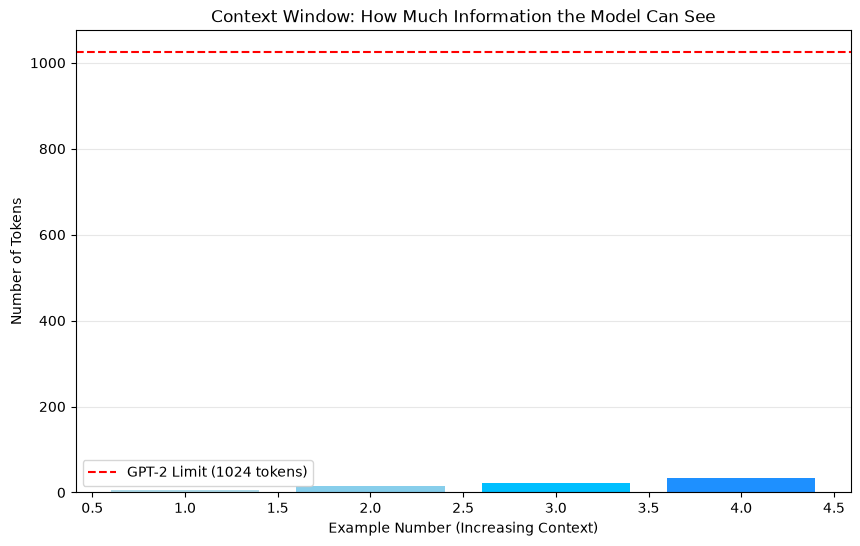

In [4]:
texts = [
    "The weather is nice today.",
    "The weather is nice today. I went for a walk in the park.",
    "The weather is nice today. I went for a walk in the park. I saw many birds and flowers.",
    "The weather is nice today. I went for a walk in the park. I saw many birds and flowers. Then I met my old friend and we had coffee together."
]

token_counts = []

for i, text in enumerate(texts, 1):
    inputs = tokenizer(text, return_tensors="pt")
    token_count = inputs.input_ids.shape[1]
    token_counts.append(token_count)

    print(f"Example {i}: {token_count} tokens")
    print(f"Text: {text}")

    with torch.no_grad():
        output = model.generate(inputs.input_ids, max_new_tokens=25, temperature=0.7, do_sample=True, pad_token_id=tokenizer.eos_token_id)
    generated = tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"Continuation: {generated[len(text):].strip()}\n")

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(texts)+1), token_counts, color=['lightblue','skyblue','deepskyblue','dodgerblue'])
plt.axhline(y=1024, color='red', linestyle='--', label='GPT-2 Limit (1024 tokens)')
plt.title('Context Window: How Much Information the Model Can See')
plt.xlabel('Example Number (Increasing Context)')
plt.ylabel('Number of Tokens')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## Key Takeaways

- **Context Window** = Model's short-term memory
- GPT-2 can only remember **1024 tokens**
- More context = better understanding, but more computation
- Modern models have much larger context windows (8k, 32k, 128k+)